In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

########################################
# CPU Optimization
########################################

os.environ["OMP_NUM_THREADS"] = "8"
os.environ["MKL_NUM_THREADS"] = "8"

torch.set_num_threads(8)
torch.set_num_interop_threads(8)

device = torch.device("cpu")

########################################
# Hierarchy Targets
########################################

# target based on distance |i-j|
target_correlations = {
    1: 0.85,
    2: 0.65,
    3: 0.45,
    4: 0.25,
    5: 0.15
}

########################################
# Dataset
########################################

class MelDataset(Dataset):

    def __init__(self, root):
        self.files = [
            os.path.join(root, f)
            for f in os.listdir(root)
            if f.endswith(".pt")
        ]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        x = torch.load(self.files[idx], weights_only=True)

        # force fixed size 80x80
        if x.shape[2] > 80:
            x = x[:, :, :80]
        else:
            pad = 80 - x.shape[2]
            x = F.pad(x, (0, pad))

        return x


train_dataset = MelDataset("data/librispeech_mel/train-clean-100")
test_dataset  = MelDataset("data/librispeech_mel/dev-clean")

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=6
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=6
)

########################################
# Hierarchical Encoder
########################################

class HierarchicalEncoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(1,32,3,stride=2,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(32,64,3,stride=2,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(64,128,3,stride=2,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.conv4 = nn.Sequential(
            nn.Conv2d(128,128,3,stride=2,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.pool = nn.AdaptiveAvgPool2d((1,1))

        self.projections = nn.ModuleList([
            nn.Linear(32,20),
            nn.Linear(64,20),
            nn.Linear(128,20),
            nn.Linear(128,20),
            nn.Linear(128,20),
            nn.Linear(128,20)
        ])

    def forward(self,x):

        f1 = self.conv1(x)
        f2 = self.conv2(f1)
        f3 = self.conv3(f2)
        f4 = self.conv4(f3)

        pooled = [
            self.pool(f1).view(x.size(0),-1),
            self.pool(f2).view(x.size(0),-1),
            self.pool(f3).view(x.size(0),-1),
            self.pool(f4).view(x.size(0),-1),
            self.pool(f4).view(x.size(0),-1),
            self.pool(f4).view(x.size(0),-1),
        ]

        z_levels = [
            self.projections[i](pooled[i])
            for i in range(6)
        ]

        z = torch.cat(z_levels, dim=1)

        return z, z_levels


########################################
# Decoder
########################################

class Decoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc = nn.Linear(120,128*5*5)

        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128,128,4,stride=2,padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(128,64,4,stride=2,padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(64,32,4,stride=2,padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(32,1,4,stride=2,padding=1)
        )

    def forward(self,z):

        x = self.fc(z)
        x = x.view(-1,128,5,5)
        x = self.deconv(x)

        return x


########################################
# Model
########################################

class HDIModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = HierarchicalEncoder()
        self.decoder = Decoder()

    def forward(self,x):

        z, levels = self.encoder(x)
        recon = self.decoder(z)

        return recon, levels


########################################
# Covariance / Correlation
########################################

def covariance(x):

    x = x - x.mean(dim=0,keepdim=True)
    cov = (x.T @ x) / (x.size(0)-1 + 1e-6)

    return cov


def correlation(x):

    cov = covariance(x)
    std = torch.sqrt(torch.diag(cov)+1e-6)

    corr = cov / (std[:,None]*std[None,:] + 1e-6)

    return corr


########################################
# Losses
########################################

def independence_loss(levels):
    z = torch.cat(levels, dim=1) # [B, 120]
    z = z - z.mean(dim=0, keepdim=True)
    
    # محاسبه ماتریس همبستگی
    cov = (z.T @ z) / (z.shape[0] - 1)
    std = torch.sqrt(torch.diag(cov) + 1e-8)
    corr = cov / (std[:, None] * std[None, :] + 1e-8)
    
    # ما می‌خواهیم کل ماتریس صفر شود (مستقل) 
    # به جز قطر اصلی (که همیشه 1 است)
    # و به جز لایه‌های مجاور (که توسط vertical_loss کنترل می‌شوند)
    
    identity = torch.eye(corr.shape[0]).to(z.device)
    
    # جریمه برای تمام همبستگی‌ها
    # با بالا بردن وزن این Loss، آن رنگ قرمز در Heatmap به سفید تبدیل می‌شود
    return torch.mean(torch.abs(corr - identity))

def independence_loss_v2(levels, threshold=0.2):
    z = torch.cat(levels, dim=1) # [B, 120]
    z = z - z.mean(dim=0, keepdim=True)
    
    # محاسبه ماتریس همبستگی
    cov = (z.T @ z) / (z.shape[0] - 1)
    std = torch.sqrt(torch.diag(cov) + 1e-8)
    corr = cov / (std[:, None] * std[None, :] + 1e-8)
    
    # ساخت یک Mask برای تشخیص جاهایی که "نباید" همبستگی داشته باشند
    # یعنی هر جایی که خارج از بلوک ۲۰*۲۰ لایه خودش و همسایه نزدیکش است
    B = corr.shape[0]
    mask = torch.ones_like(corr)
    
    for i in range(6):
        start, end = i*20, (i+1)*20
        # لایه خودش را جریمه نکن (چون داخل لایه همبستگی می‌خواهیم)
        mask[start:end, start:end] = 0
        
        # لایه بلافاصله قبلی و بعدی را هم کمتر جریمه کن (برای حفظ Hierarchy)
        if i > 0: mask[(i-1)*20:i*20, start:end] = 0.5
        if i < 5: mask[(i+1)*20:(i+2)*20, start:end] = 0.5

    # Hinge Loss: فقط اگر همبستگی از حد آستانه (threshold) بالاتر بود جریمه کن
    excess_corr = torch.abs(corr) - threshold
    excess_corr = torch.clamp(excess_corr, min=0) # فقط مقادیر مثبت
    
    return torch.mean(excess_corr * mask)



def vertical_correlation_loss(levels):

    loss = 0

    for i in range(len(levels)):
        for j in range(i+1,len(levels)):

            distance = j - i
            target = target_correlations[distance]

            zi = levels[i]
            zj = levels[j]

            corr = correlation(torch.cat([zi,zj],dim=1))
            cross = corr[:zi.size(1), zi.size(1):]

            #loss += ((cross - target)**2).mean()
            loss += F.relu(target - cross).mean()


    return loss


def orthogonality_loss(levels):

    loss = 0

    for z in levels:
        cov = covariance(z)
        I = torch.eye(cov.size(0), device=z.device)
        loss += ((cov - I)**2).mean()

    return loss


########################################
# Improved Training (HDI Enforcement Phase)
########################################

model = HDIModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 30 # کمی بیشتر برای جا افتادن استقلال

best_loss = float("inf")
save_path = "hdi_model_best.pt"


for epoch in range(epochs):
    model.train()
    total_rec, total_vert, total_ind, total_ortho, total_sparse = 0, 0, 0, 0, 0

    ########################################
    # Phase Scheduling (Aggressive Disentanglement)
    ########################################
    if epoch < 5:
        # Phase 1: Warming up reconstruction
        w_rec, w_vert, w_ind, w_ortho, w_sparse = 1.0, 0.0, 0.0, 0.0, 0.0
    elif epoch < 12:
        # Phase 2: Start pushing hierarchy but with STRONG independence
        w_rec, w_vert, w_ind, w_ortho, w_sparse = 1.0, 0.5, 0.8, 0.1, 0.01
    elif epoch < 20:
        # Phase 3: Fine-tuning - High independence to "clean" the heatmap
        w_rec, w_vert, w_ind, w_ortho, w_sparse = 1.0, 0.8, 1.5, 0.2, 0.02
    else:
    # در فاز نهایی (مثلاً اپوک ۲۰ تا ۳۰)
        w_rec = 1.0
        w_vert = 0.5    # کمی کاهش برای آزادی بیشتر در استقلال
        w_ind = 5.0     # افزایش شدید برای سفید کردن Heatmap
        w_ortho = 0.3   # کمک به نظم داخلی هر لایه
        w_sparse = 0.05 # حذف ابعاد بلااستفاده


    ########################################

    for batch in train_loader:
        batch = batch.to(device)
        recon, levels = model(batch)

        # 1. Reconstruction Loss
        loss_rec = F.mse_loss(recon, batch)
        
        # 2. Vertical Loss (Hierarchy)
        loss_vert = vertical_correlation_loss(levels)
        
        # 3. Independence Loss (The "Whitening" force)
        # نکته: این تابع باید جریمه سنگینی روی همبستگی‌های خارج از ساختار سلسله‌مراتبی بگذارد
        #loss_ind = independence_loss(levels)
        loss_ind = independence_loss_v2(levels)
        
        # 4. Orthogonality (Intra-level structure)
        loss_ortho = orthogonality_loss(levels)

        # 5. Sparsity Loss (L1) - برای حذف نویزهای قرمز در Heatmap
        # کمک می‌کند ابعاد غیرضروری صفر شوند
        all_latents = torch.cat(levels, dim=1)
        loss_sparse = torch.mean(torch.abs(all_latents))

        loss = (
            w_rec * loss_rec
            + w_vert * loss_vert
            + w_ind * loss_ind
            + w_ortho * loss_ortho
            + w_sparse * loss_sparse
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_rec += loss_rec.item()
        total_vert += loss_vert.item()
        total_ind += loss_ind.item()
        total_ortho += loss_ortho.item()
        total_sparse += loss_sparse.item()

        ##############
        n = len(train_loader)
        epoch_loss = total_rec / n

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "loss": epoch_loss
            }, save_path)
        
            print("Model saved ✅")


    n = len(train_loader)
    print(f"Epoch {epoch} | Rec: {total_rec/n:.4f} | Vert: {total_vert/n:.4f} | Ind: {total_ind/n:.4f} | Sparse: {total_sparse/n:.4f}")



 
##############



Model saved ✅
Epoch 0 | Rec: 0.4446 | Vert: 8.9595 | Ind: 0.0912 | Sparse: 0.1222
Model saved ✅
Epoch 1 | Rec: 0.3305 | Vert: 8.9000 | Ind: 0.0541 | Sparse: 0.0890
Model saved ✅
Epoch 2 | Rec: 0.2940 | Vert: 8.8912 | Ind: 0.0453 | Sparse: 0.0876
Model saved ✅
Epoch 3 | Rec: 0.2755 | Vert: 8.8880 | Ind: 0.0412 | Sparse: 0.0876
Epoch 4 | Rec: 0.2649 | Vert: 8.8869 | Ind: 0.0382 | Sparse: 0.0883
Epoch 5 | Rec: 0.3206 | Vert: 0.1322 | Ind: 0.3517 | Sparse: 0.2078
Epoch 6 | Rec: 0.2792 | Vert: 0.0461 | Ind: 0.3423 | Sparse: 0.2082
Epoch 7 | Rec: 0.2709 | Vert: 0.0452 | Ind: 0.3349 | Sparse: 0.2071
Epoch 8 | Rec: 0.2642 | Vert: 0.0420 | Ind: 0.3316 | Sparse: 0.2037
Epoch 9 | Rec: 0.2597 | Vert: 0.0391 | Ind: 0.3261 | Sparse: 0.2017
Epoch 10 | Rec: 0.2557 | Vert: 0.0392 | Ind: 0.3237 | Sparse: 0.1965
Epoch 11 | Rec: 0.2521 | Vert: 0.0396 | Ind: 0.3218 | Sparse: 0.1938
Epoch 12 | Rec: 0.2528 | Vert: 0.0464 | Ind: 0.3180 | Sparse: 0.1900
Epoch 13 | Rec: 0.2513 | Vert: 0.0417 | Ind: 0.3151 | Spa

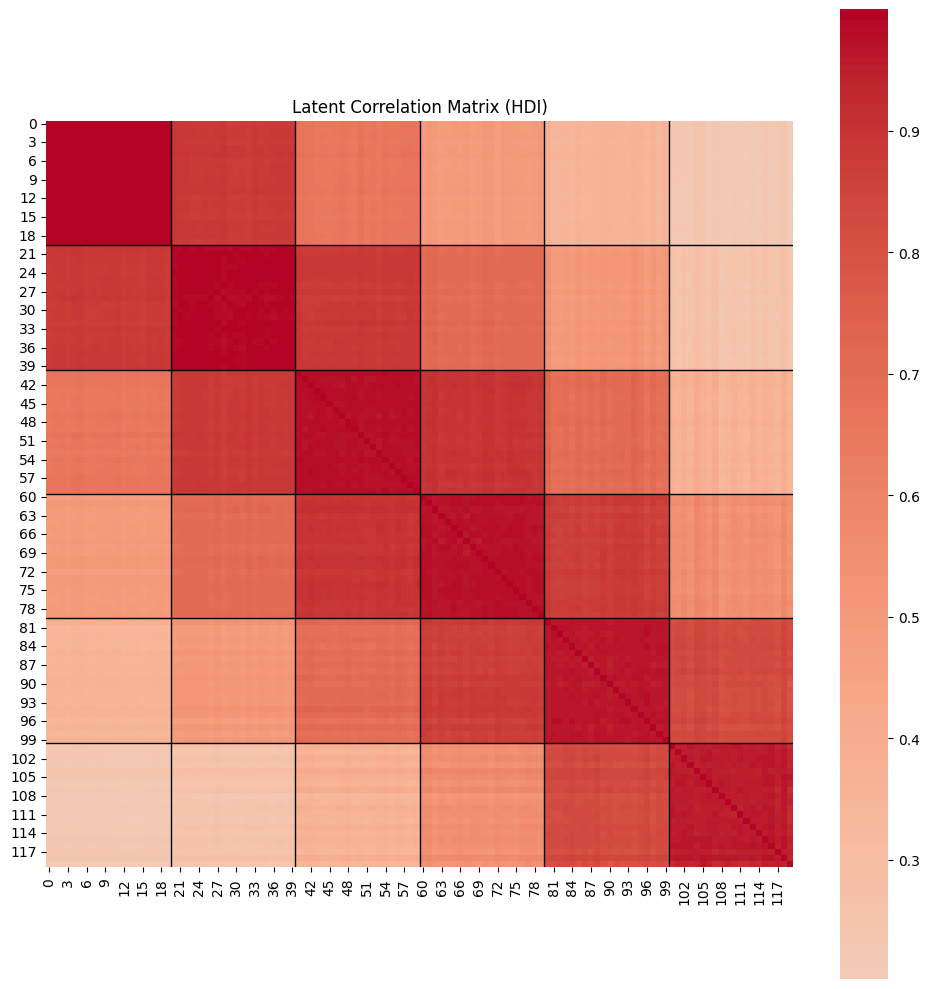

In [3]:
########################################
# Latent Correlation Visualization
########################################

import numpy as np
import seaborn as sns

model.eval()

latents = []

with torch.no_grad():

    for batch in test_loader:

        batch = batch.to(device)

        z, _ = model.encoder(batch)

        latents.append(z.cpu())

latent_matrix = torch.cat(latents, dim=0)

# normalize]=[>??
latent_matrix = latent_matrix - latent_matrix.mean(dim=0)

cov = (latent_matrix.T @ latent_matrix) / (latent_matrix.shape[0]-1)

std = torch.sqrt(torch.diag(cov) + 1e-8)

corr = cov / (std[:,None] * std[None,:] + 1e-8)

corr = corr.numpy()

plt.figure(figsize=(10,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar=True
)

# level boundaries
for i in range(1,6):
    plt.axhline(i*20,color='black',linewidth=1)
    plt.axvline(i*20,color='black',linewidth=1)

plt.title("Latent Correlation Matrix (HDI)")
plt.tight_layout()
plt.show()

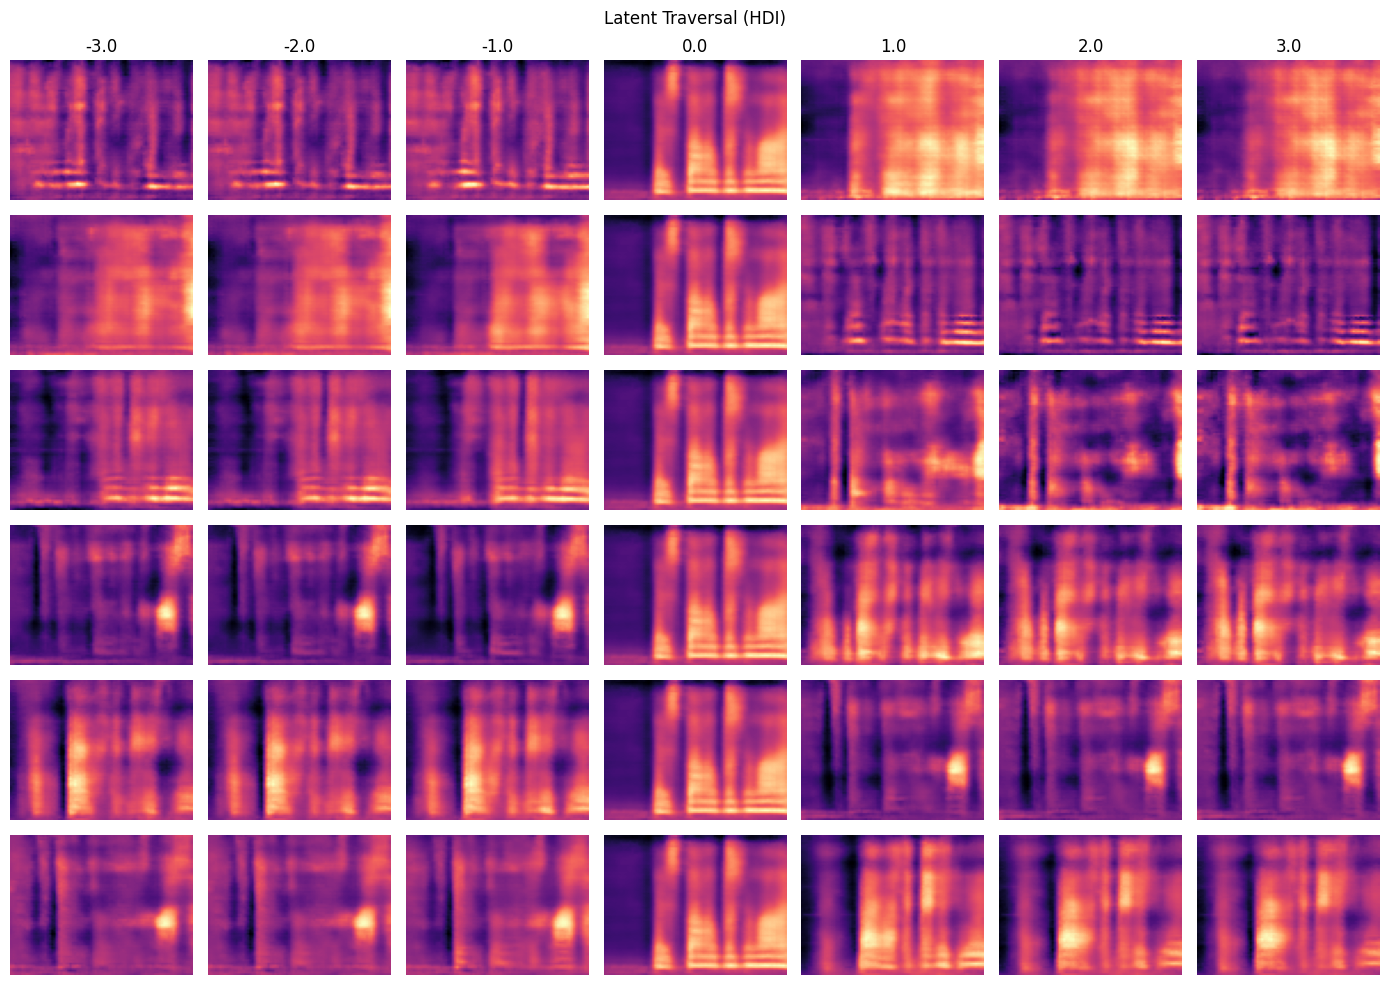

In [4]:
########################################
# Latent Traversal Visualization
########################################

model.eval()

sample = next(iter(test_loader))
sample = sample[0:1].to(device)

with torch.no_grad():
    
    z, _ = model.encoder(sample)

z = z.clone()

steps = torch.linspace(-3,3,7).to(device)

level_dim = 20
levels = 6

fig, axes = plt.subplots(levels, len(steps), figsize=(14,10))

for lvl in range(levels):

    start = lvl*level_dim
    end = start+level_dim

    for i,step in enumerate(steps):

        z_mod = z.clone()

        z_mod[:,start:end] += step

        with torch.no_grad():
            recon = model.decoder(z_mod)

        spec = recon.squeeze().cpu().numpy()

        axes[lvl,i].imshow(spec,aspect="auto",origin="lower",cmap="magma")
        axes[lvl,i].axis("off")

        if lvl == 0:
            axes[lvl,i].set_title(f"{step:.1f}")

    axes[lvl,0].set_ylabel(f"Level {lvl+1}")

plt.suptitle("Latent Traversal (HDI)")
plt.tight_layout()
plt.show()
